In [ ]:
from src.model import Model
from src.data_utils import download_data, get_raw_data, normalize_data, label_anomalies, make_graph_data, generate_anomaly_labels
from src.metrics import anomaly_threshold, find_thresholds, calculate_delays, calculate_auc, compute_forward_cycle_mmd
import numpy as np
import pandas as pd
import torch
from torch_geometric.loader import DataLoader
from sklearn.decomposition import PCA
import argparse
import random
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmasher as cmr



In [2]:
parser = argparse.ArgumentParser()
parser.add_argument('--random_seed',  type=int, default=42)
parser.add_argument('--num_epochs', type=int, default=10, help='number of training epochs')
parser.add_argument('--lr_GE', type=float, default=1e-3, help='generator/encoder learning rate')
parser.add_argument('--lr_D', type=float, default=5e-6, help='discriminator learning rate')
parser.add_argument('--cc_weight', type=float, default=0.01, help='cycle consistency coefficient')
parser.add_argument('--dropout_p', type=float, default=0.1, help='dropout rate')
parser.add_argument('--batch_size', type=int, default=32, help='number of samples per forward/backward pass')
parser.add_argument('--verbose',  type=bool, default=False, help='print loss during training')
parser.add_argument('--feature_size', type=int, default=3, help='input feature dimension')
parser.add_argument('--hidden_size', type=int, default=64, help='hidden feature dimension')
parser.add_argument('--latent_size', type=int, default=128, help='latent feature dimension')
parser.add_argument('--num_layers', type=int, default=1, help='number of hidden layers')
parser.add_argument('--num_nodes', type=int, default=196, help='total number of nodes in the graph')
parser.add_argument('--replicate_latent', type=bool, default=False, help='replicate latent features for every node')
parser.add_argument('--repeats_D', type=int, default=1, help='number of discriminator updates per generator/encoder update')
parser.add_argument('--repeats_GE', type=int, default=2, help='number of generator/encoder updates per discriminator update')
parser.add_argument('--pretrained',  type=bool, default=True, help='use the pretrained model')
args = parser.parse_args(args=[])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_path = './data/'
model_save_path = './saved_model/'

np.random.seed(args.random_seed)
random.seed(args.random_seed)
torch.manual_seed(args.random_seed)

download_data(data_path)
train_df = get_raw_data(data_path + 'nashville_freeway_anomaly.csv')
min_vals = {'speed':math.floor(train_df['speed'].min()), 
            'occ':math.floor(train_df['occ'].min()), 
            'volume':math.floor(train_df['volume'].min())}
max_vals = {'speed':math.ceil(train_df['speed'].max()), 
            'occ':math.ceil(train_df['occ'].max()), 
            'volume':math.ceil(train_df['volume'].max())}

train_df = normalize_data(train_df, min_vals, max_vals)
train_df = label_anomalies(train_df)
train_data = make_graph_data(train_df)
train_loader = DataLoader(train_data, args.batch_size, shuffle=True)

model = Model(args, device)

# train the model if not using a pretrained one
if not args.pretrained:
    recon_errors = []
    stats = {}
    loss_hist = model.train(train_loader)

nashville_freeway_anomaly.csv already exists, skipping download


Preparing Data:   0%|          | 0/13440 [00:00<?, ?it/s]

### Anomaly Detection Analysis

In [3]:
# determine reconstruction error on anomaly-free test data
clean_test_df = get_raw_data(data_path + 'nashville_freeway_anomaly.csv', train=False)
clean_test_data = normalize_data(clean_test_df, min_vals, max_vals)
clean_test_data = label_anomalies(clean_test_data)
clean_test_data = make_graph_data(clean_test_data, hide_anomalies=True)
clean_test_errors, clean_test_true_speeds, clean_test_recon_speeds = model.test(clean_test_data, model_save_path)
print(f'Reconstruction error on anomaly-free test data: {np.mean(clean_test_errors):.5f}')

Preparing Data:   0%|          | 0/4800 [00:00<?, ?it/s]

Reconstruction error on anomaly-free test data: 0.00608


In [4]:
# determine reconstruction error on test data with anomalies
test_df = get_raw_data(data_path + 'nashville_freeway_anomaly.csv', train=False)
test_data = normalize_data(test_df, min_vals, max_vals)
test_data = label_anomalies(test_data)
test_data = make_graph_data(test_data, hide_anomalies=False)
test_errors, test_true_speeds, test_recon_speeds = model.test(test_data, model_save_path)

Preparing Data:   0%|          | 0/4800 [00:00<?, ?it/s]

In [5]:
crash_reported = test_df['crash_record'].to_numpy()[0::196]
anomaly_labels = generate_anomaly_labels(test_df)
thresh = anomaly_threshold(train_data, model, torch.tensor([1., 1., 1.]))
thresholds = find_thresholds(thresh, test_errors, anomaly_labels)

In [6]:
# calculate delays in detecting anomalies 
calculate_delays(thresh, test_errors, anomaly_labels, crash_reported)

1.0% FPR -- Reporting Delay: -5.06 +/- 9.61, Miss Percentage: 33.33%.
2.5% FPR -- Reporting Delay: -8.22 +/- 8.83, Miss Percentage: 25.00%.
5.0% FPR -- Reporting Delay: -7.77 +/- 9.18, Miss Percentage: 8.33%.
10.0% FPR -- Reporting Delay: -10.58 +/- 7.31, Miss Percentage: 0.00%.


In [7]:
# calculate area under the ROC curve (AUC)
AUC = calculate_auc(test_errors, anomaly_labels)
print(f'AUC: {AUC:.4f}')

AUC: 0.7329


### Case Study Analysis

In [8]:
milemarkers = np.array([53.3, 53.6, 53.9, 54.1, 54.6, 55. , 55.3, 55.5, 56. , 56.3, 
                        56.7, 57.3, 57.7, 58.1, 58.3, 58.6, 58.8, 59. , 59.3, 59.7, 
                        60. , 60.4, 60.5, 61. , 61.5, 62.1, 62.5, 63.1, 63.6, 64. , 
                        64.3, 64.5, 64.8, 65. , 65.1, 65.6, 65.9, 66.3, 66.5, 66.7, 
                        66.9, 67.3, 67.8, 68.2, 68.5, 68.8, 69.3, 69.8, 70.1])

In [9]:
def create_result_df(anomaly_preds, true_speeds, recon_speeds, milemarkers):
    mms = milemarkers[np.arange(anomaly_preds.shape[1]) // 4]
    mms = np.tile(mms, anomaly_preds.shape[0])

    lanes = np.arange(anomaly_preds.shape[1]) % 4 + 1
    lanes = np.tile(lanes, anomaly_preds.shape[0])

    times = np.arange(anomaly_preds.shape[0])
    times = np.repeat(times, anomaly_preds.shape[1])
    
    df = pd.DataFrame({'Anomaly': anomaly_preds.flatten(), 
                       'Lane Number': lanes, 
                       'Milemarker': mms, 
                       'Time Index': times, 
                       'Speed': true_speeds.flatten(), 
                       'Reconstructed Speed': recon_speeds.flatten()
                      })
    return df


##### - Carsh event on October 11, 2023

In [10]:
case_df = test_df[test_df['day']==10]
case_data = normalize_data(case_df, min_vals, max_vals)
case_data = label_anomalies(case_data)
case_data = make_graph_data(case_data, hide_anomalies=False)
case_errors, case_true_speeds, case_recon_speeds = model.test(case_data, model_save_path)
offset_10_idx = thresholds.shape[0] - 1 - np.argmin(np.abs(thresholds[:, 0][::-1] - 0.1))
offset_10 = thresholds[offset_10_idx, 1]
anomaly_preds_10 = (case_errors > (thresh + offset_10)).astype('int')

Preparing Data:   0%|          | 0/960 [00:00<?, ?it/s]

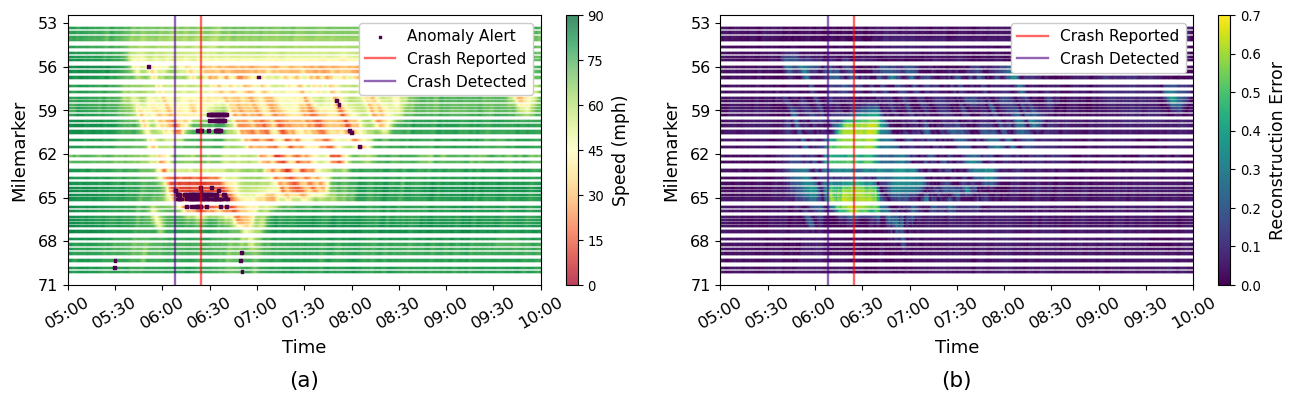

In [11]:
df = create_result_df(anomaly_preds_10, case_true_speeds, case_recon_speeds, milemarkers)
df['Time Index'] = pd.to_datetime((df['Time Index'] + 1) * 30 + 14400, unit='s')
lane_df = df[df['Lane Number'] == 1]
filtered_df = lane_df[lane_df['Anomaly'] == 1]
crash_reported = np.where(np.array(case_df['crash_record']==1))[0][0::196][0] / 196
crash_reported = pd.to_datetime(crash_reported * 30 + 14400, unit='s') 
crash_detected = filtered_df.iloc[3]['Time Index']

fig, ax = plt.subplots(1, 2, figsize=(15, 3.5))
ax0 = ax[0].scatter(lane_df['Time Index'].values, 
                    lane_df['Milemarker'].values, 
                    c=lane_df['Speed'].values * (max_vals['speed'] - min_vals['speed']) + min_vals['speed'], 
                    norm=colors.Normalize(vmin=0, vmax=90),
                    marker='s',s=1, cmap='RdYlGn', alpha=0.75)
ax[0].scatter(filtered_df['Time Index'], 
              filtered_df['Milemarker'].values, 
              c=filtered_df['Anomaly'].values, marker='s', s=4, cmap='BuPu_r', label='Anomaly Alert', alpha=1)
ax[0].axvline(x=crash_reported, color='red', linestyle='-', linewidth=1.7, label='Crash Reported', alpha=0.6)
ax[0].axvline(x=crash_detected, color='indigo', linestyle='-', linewidth=1.7, label='Crash Detected', alpha=0.6)
ax[0].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[0].tick_params(axis='x', labelrotation=30, labelsize=12)
start_time = pd.to_datetime('1970-01-01 05:00:00')
end_time = pd.to_datetime('1970-01-01 10:00:00')
ax[0].set_xlim(start_time, end_time)
ax[0].set_xlabel('Time', fontsize=13, labelpad=5)
ax[0].set_yticks(np.arange(53, 72, 3))
ax[0].set_yticklabels(np.arange(53, 72, 3), fontsize=11.5)
ax[0].invert_yaxis()
ax[0].set_ylabel('Milemarker', fontsize=13, labelpad=7)
ax[0].set_title('(a)', fontsize=15.5, y=-0.41)
ax[0].legend(loc='upper right', fontsize=11, framealpha=1)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='2.5%', pad=0.25)
cbar = fig.colorbar(ax0, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=9.5)
cbar.set_label('Speed (mph)', fontsize=12.4, labelpad=6)
tick_locator = mpl.ticker.MaxNLocator(nbins=6)
cbar.locator = tick_locator
cbar.update_ticks()

cmap = cmr.get_sub_cmap('viridis', 0, 1)
ax1 = ax[1].scatter(lane_df['Time Index'].values, 
                    lane_df['Milemarker'].values, 
                    c=np.abs(lane_df['Reconstructed Speed'].values-lane_df['Speed'].values), 
                    norm=colors.Normalize(vmin=0, vmax=0.7),
                    marker='s', s=1, cmap=cmap)
ax[1].axvline(x=crash_reported, color='red', linestyle='-', linewidth=1.7, label='Crash Reported', alpha=0.6)
ax[1].axvline(x=crash_detected, color='indigo', linestyle='-', linewidth=1.7, label='Crash Detected', alpha=0.6)
ax[1].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[1].tick_params(axis='x', labelrotation=30, labelsize=12)
start_time = pd.to_datetime('1970-01-01 05:00:00')
end_time = pd.to_datetime('1970-01-01 10:00:00')
ax[1].set_xlim(start_time, end_time)
ax[1].set_xlabel('Time', fontsize=13, labelpad=5)
ax[1].set_yticks(np.arange(53, 72, 3))
ax[1].set_yticklabels(np.arange(53, 72, 3), fontsize=11.5)
ax[1].invert_yaxis()
ax[1].set_ylabel('Milemarker', fontsize=13, labelpad=7)
ax[1].set_title('(b)', fontsize=15.5, y=-0.41)
ax[1].legend(loc='upper right', fontsize=11, framealpha=1)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='2.5%', pad=0.25)
cbar = fig.colorbar(ax1, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=9.5)
cbar.set_label('Reconstruction Error', fontsize=12.5, labelpad=6)
tick_locator = mpl.ticker.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

plt.subplots_adjust(wspace=0.28)
# plt.savefig('Figure4.png', dpi=600, bbox_inches='tight', facecolor='white', pad_inches=0.5)

##### - Carsh event on October 26, 2023

In [12]:
case_df = test_df[test_df['day']==25]
case_data = normalize_data(case_df, min_vals, max_vals)
case_data = label_anomalies(case_data)
case_data = make_graph_data(case_data, hide_anomalies=False)
case_errors, case_true_speeds, case_recon_speeds = model.test(case_data, model_save_path)
offset_10_idx = thresholds.shape[0] - 1 - np.argmin(np.abs(thresholds[:, 0][::-1] - 0.1))
offset_10 = thresholds[offset_10_idx, 1]
anomaly_preds_10 = (case_errors > (thresh + offset_10)).astype('int')

Preparing Data:   0%|          | 0/960 [00:00<?, ?it/s]

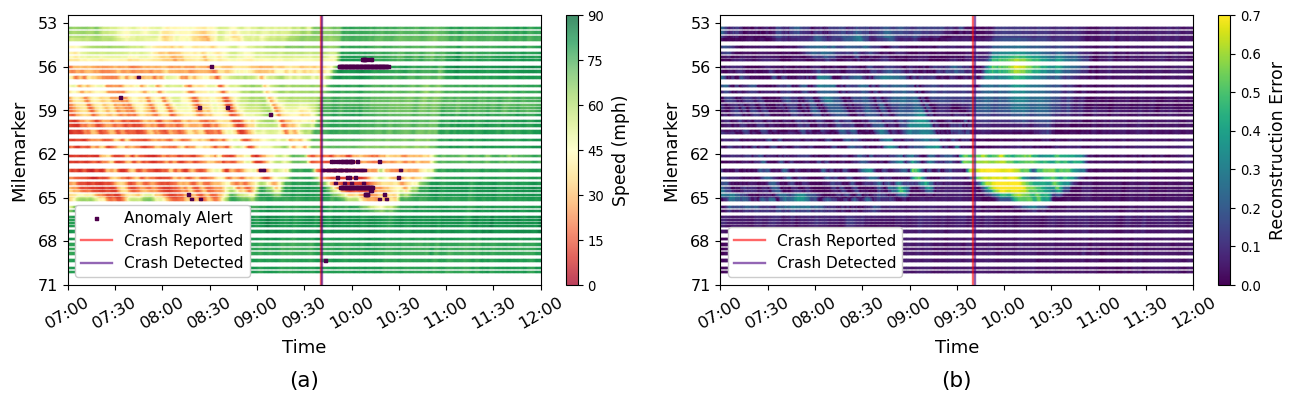

In [13]:
df = create_result_df(anomaly_preds_10, case_true_speeds, case_recon_speeds, milemarkers)
df['Time Index'] = pd.to_datetime((df['Time Index'] + 1) * 30 + 14400, unit='s')
lane_df = df[df['Lane Number'] == 1]
filtered_df = lane_df[lane_df['Anomaly'] == 1]
crash_reported = np.where(np.array(case_df['crash_record']==1))[0][0::196][1] / 196
crash_reported = pd.to_datetime(crash_reported * 30 + 14400, unit='s') 
crash_detected = filtered_df.iloc[30]['Time Index']

fig, ax = plt.subplots(1, 2, figsize=(15, 3.5))
ax0 = ax[0].scatter(lane_df['Time Index'].values, 
                    lane_df['Milemarker'].values, 
                    c=lane_df['Speed'].values * (max_vals['speed'] - min_vals['speed']) + min_vals['speed'], 
                    norm=colors.Normalize(vmin=0, vmax=90),
                    marker='s',s=1, cmap='RdYlGn', alpha=0.75)
ax[0].scatter(filtered_df['Time Index'], 
              filtered_df['Milemarker'].values, 
              c=filtered_df['Anomaly'].values, marker='s', s=4, cmap='BuPu_r', label='Anomaly Alert', alpha=1)
ax[0].axvline(x=crash_reported, color='red', linestyle='-', linewidth=1.7, label='Crash Reported', alpha=0.6)
ax[0].axvline(x=crash_detected, color='indigo', linestyle='-', linewidth=1.7, label='Crash Detected', alpha=0.6)
ax[0].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[0].tick_params(axis='x', labelrotation=30, labelsize=12)
start_time = pd.to_datetime('1970-01-01 07:00:00')
end_time = pd.to_datetime('1970-01-01 12:00:00')
ax[0].set_xlim(start_time, end_time)
ax[0].set_xlabel('Time', fontsize=13, labelpad=5)
ax[0].set_yticks(np.arange(53, 72, 3))
ax[0].set_yticklabels(np.arange(53, 72, 3), fontsize=11.5)
ax[0].invert_yaxis()
ax[0].set_ylabel('Milemarker', fontsize=13, labelpad=7)
ax[0].set_title('(a)', fontsize=15.5, y=-0.41)
ax[0].legend(loc='lower left', fontsize=11, framealpha=1)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='2.5%', pad=0.25)
cbar = fig.colorbar(ax0, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=9.5)
cbar.set_label('Speed (mph)', fontsize=12.4, labelpad=6)
tick_locator = mpl.ticker.MaxNLocator(nbins=6)
cbar.locator = tick_locator
cbar.update_ticks()

cmap = cmr.get_sub_cmap('viridis', 0, 1)
ax1 = ax[1].scatter(lane_df['Time Index'].values, 
                    lane_df['Milemarker'].values, 
                    c=np.abs(lane_df['Reconstructed Speed'].values-lane_df['Speed'].values), 
                    norm=colors.Normalize(vmin=0, vmax=0.7),
                    marker='s', s=1, cmap=cmap)
ax[1].axvline(x=crash_reported, color='red', linestyle='-', linewidth=1.7, label='Crash Reported', alpha=0.6)
ax[1].axvline(x=crash_detected, color='indigo', linestyle='-', linewidth=1.7, label='Crash Detected', alpha=0.6)
ax[1].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[1].tick_params(axis='x', labelrotation=30, labelsize=12)
start_time = pd.to_datetime('1970-01-01 07:00:00')
end_time = pd.to_datetime('1970-01-01 12:00:00')
ax[1].set_xlim(start_time, end_time)
ax[1].set_xlabel('Time', fontsize=13, labelpad=5)
ax[1].set_yticks(np.arange(53, 72, 3))
ax[1].set_yticklabels(np.arange(53, 72, 3), fontsize=11.5)
ax[1].invert_yaxis()
ax[1].set_ylabel('Milemarker', fontsize=13, labelpad=7)
ax[1].set_title('(b)', fontsize=15.5, y=-0.41)
ax[1].legend(loc='lower left', fontsize=11, framealpha=1)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='2.5%', pad=0.25)
cbar = fig.colorbar(ax1, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=9.5)
cbar.set_label('Reconstruction Error', fontsize=12.5, labelpad=6)
tick_locator = mpl.ticker.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

plt.subplots_adjust(wspace=0.28)
# plt.savefig('FigureS3.png', dpi=600, bbox_inches='tight', facecolor='white', pad_inches=0.5)

##### - Carsh event on October 16, 2023

In [14]:
case_df = test_df[test_df['day']==15]
case_data = normalize_data(case_df, min_vals, max_vals)
case_data = label_anomalies(case_data)
case_data = make_graph_data(case_data, hide_anomalies=False)
case_errors, case_true_speeds, case_recon_speeds = model.test(case_data, model_save_path)
offset_10_idx = thresholds.shape[0] - 1 - np.argmin(np.abs(thresholds[:, 0][::-1] - 0.1))
offset_10 = thresholds[offset_10_idx, 1]
anomaly_preds_10 = (case_errors > (thresh + offset_10)).astype('int')

Preparing Data:   0%|          | 0/960 [00:00<?, ?it/s]

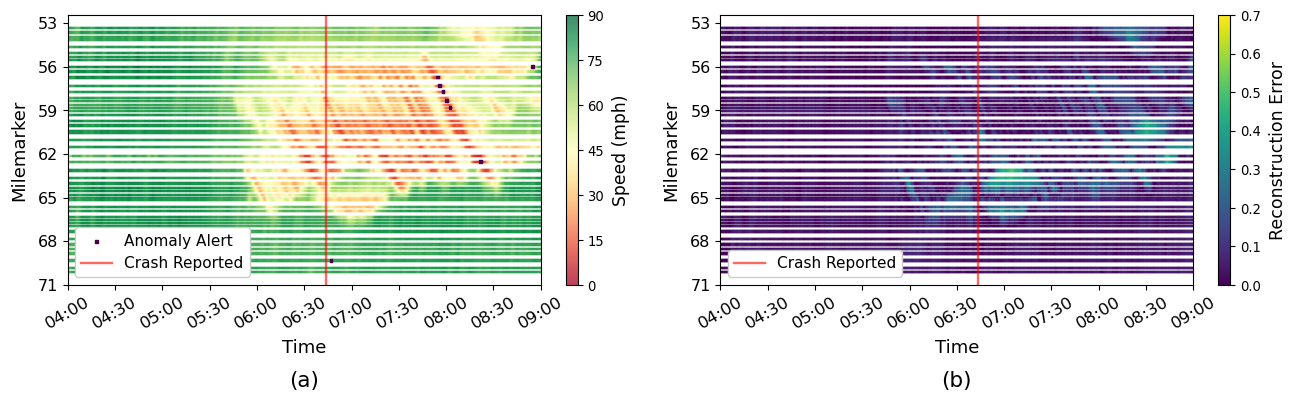

In [15]:
df = create_result_df(anomaly_preds_10, case_true_speeds, case_recon_speeds, milemarkers)
df['Time Index'] = pd.to_datetime((df['Time Index'] + 1) * 30 + 14400, unit='s')
lane_df = df[df['Lane Number'] == 1]
filtered_df = lane_df[lane_df['Anomaly'] == 1]
crash_reported = np.where(np.array(case_df['crash_record']==1))[0][0::196][0] / 196
crash_reported = pd.to_datetime(crash_reported * 30 + 14400, unit='s') 

fig, ax = plt.subplots(1, 2, figsize=(15, 3.5))
ax0 = ax[0].scatter(lane_df['Time Index'].values, 
                    lane_df['Milemarker'].values, 
                    c=lane_df['Speed'].values * (max_vals['speed'] - min_vals['speed']) + min_vals['speed'], 
                    norm=colors.Normalize(vmin=0, vmax=90),
                    marker='s',s=1, cmap='RdYlGn', alpha=0.75)
ax[0].scatter(filtered_df['Time Index'], 
              filtered_df['Milemarker'].values, 
              c=filtered_df['Anomaly'].values, marker='s', s=4, cmap='BuPu_r', label='Anomaly Alert', alpha=1)
ax[0].axvline(x=crash_reported, color='red', linestyle='-', linewidth=1.7, label='Crash Reported', alpha=0.6)
ax[0].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[0].tick_params(axis='x', labelrotation=30, labelsize=12)
start_time = pd.to_datetime('1970-01-01 04:00:00')
end_time = pd.to_datetime('1970-01-01 09:00:00')
ax[0].set_xlim(start_time, end_time)
ax[0].set_xlabel('Time', fontsize=13, labelpad=5)
ax[0].set_yticks(np.arange(53, 72, 3))
ax[0].set_yticklabels(np.arange(53, 72, 3), fontsize=11.5)
ax[0].invert_yaxis()
ax[0].set_ylabel('Milemarker', fontsize=13, labelpad=7)
ax[0].set_title('(a)', fontsize=15.5, y=-0.41)
ax[0].legend(loc='lower left', fontsize=11, framealpha=1)
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='2.5%', pad=0.25)
cbar = fig.colorbar(ax0, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=9.5)
cbar.set_label('Speed (mph)', fontsize=12.4, labelpad=6)
tick_locator = mpl.ticker.MaxNLocator(nbins=6)
cbar.locator = tick_locator
cbar.update_ticks()

cmap = cmr.get_sub_cmap('viridis', 0, 1)
ax1 = ax[1].scatter(lane_df['Time Index'].values, 
                    lane_df['Milemarker'].values, 
                    c=np.abs(lane_df['Reconstructed Speed'].values-lane_df['Speed'].values), 
                    norm=colors.Normalize(vmin=0, vmax=0.7),
                    marker='s', s=1, cmap=cmap)
ax[1].axvline(x=crash_reported, color='red', linestyle='-', linewidth=1.7, label='Crash Reported', alpha=0.6)
ax[1].xaxis.set_major_locator(mdates.MinuteLocator(byminute=[0, 30]))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[1].tick_params(axis='x', labelrotation=30, labelsize=12)
start_time = pd.to_datetime('1970-01-01 04:00:00')
end_time = pd.to_datetime('1970-01-01 09:00:00')
ax[1].set_xlim(start_time, end_time)
ax[1].set_xlabel('Time', fontsize=13, labelpad=5)
ax[1].set_yticks(np.arange(53, 72, 3))
ax[1].set_yticklabels(np.arange(53, 72, 3), fontsize=11.5)
ax[1].invert_yaxis()
ax[1].set_ylabel('Milemarker', fontsize=13, labelpad=7)
ax[1].set_title('(b)', fontsize=15.5, y=-0.41)
ax[1].legend(loc='lower left', fontsize=11, framealpha=1)
divider = make_axes_locatable(ax[1])
cax = divider.append_axes('right', size='2.5%', pad=0.25)
cbar = fig.colorbar(ax1, cax=cax, orientation='vertical')
cbar.ax.tick_params(labelsize=9.5)
cbar.set_label('Reconstruction Error', fontsize=12.5, labelpad=6)
tick_locator = mpl.ticker.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

plt.subplots_adjust(wspace=0.28)
# plt.savefig('FigureS4.png', dpi=600, bbox_inches='tight', facecolor='white', pad_inches=0.5)

### Distributional Comparison

In [16]:
forward_mmd = compute_forward_cycle_mmd(model, train_loader)
print("Forward cycle MMD (G(E(x)) ≈ x):", forward_mmd)


Forward cycle MMD (G(E(x)) ≈ x): 0.0009235143661499023


In [17]:
def plot_node_embeddings(model, loader, num_samples=2000):
    """
    Plots 2D PCA of real node embeddings vs reconstructed node embeddings.
    """
    model.netG.eval()
    model.netE.eval()
    
    real_nodes = []
    recon_nodes = []

    for data in loader:
        if len(real_nodes) >= num_samples:
            break
        
        data = data.to(model.device)
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Forward cycle reconstruction
        z = model.netE(x, edge_index, batch)
        x_recon = model.netG(z, edge_index)

        real_nodes.append(x)
        recon_nodes.append(x_recon)
    
    real_nodes = torch.cat(real_nodes, dim=0)[:num_samples].cpu().numpy()
    recon_nodes = torch.cat(recon_nodes, dim=0)[:num_samples].cpu().detach().numpy()

    # PCA to 2D
    pca = PCA(n_components=2)
    combined = np.concatenate([real_nodes, recon_nodes], axis=0)
    pca_result = pca.fit_transform(combined)
    
    n_real = real_nodes.shape[0]
    real_pca = pca_result[:n_real]
    recon_pca = pca_result[n_real:]

    # Scatter plot
    plt.figure(figsize=(7,5))
    plt.scatter(real_pca[:,0], real_pca[:,1], alpha=0.5, label='Real nodes', color='blue')
    plt.scatter(recon_pca[:,0], recon_pca[:,1], alpha=0.5, label='Regenerated nodes', color='orange')
    plt.xlabel('PCA Component 1', fontsize=12)
    plt.ylabel('PCA Component 2', fontsize=12)
    # plt.title('Real vs Reconstructed Node Embeddings (PCA)')
    plt.legend(loc='upper right', fontsize=12)
    plt.show()

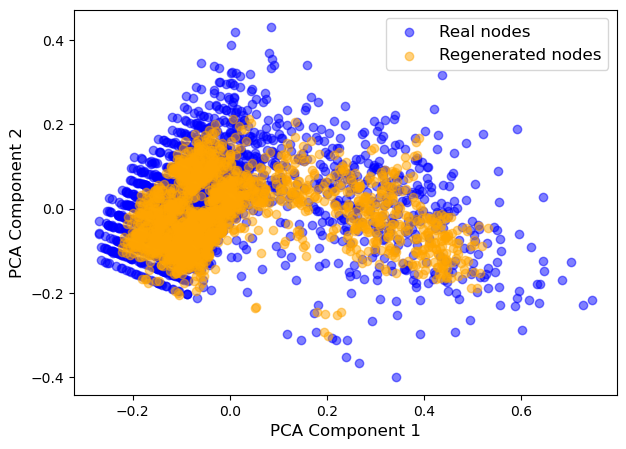

In [ ]:
# PCA scatter plot
plot_node_embeddings(model, train_loader)